# Проект: Определение токсичных комментариев

**Описание проекта**

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.


**Цель исследования**

Разработать инструмент для автоматического выявления токсичных комментариев и их направления на модерацию, чтобы повысить качество коммуникации и безопасность платформы.


**Ход исследования**

Для достижения поставленной цели будут выполнены следующие шаги:

- Ознакомление с данными и анализ структуры датасета.
- Предобработка текста: очистка, лемматизация, удаление дубликатов.
- Исследовательский анализ данных (EDA), включающий анализ баланса классов и частотный анализ слов.
- Построение и настройка моделей классификации текста (Logistic Regression, ComplementNB, LGBMClassifier).
- Сравнение моделей по метрике F1 и выбор финальной модели для использования в системе модерации.

Также в заключительной части проекта будут сформулированы итоговые выводы и рекомендации для заказчика.

## Настройка среды

In [1]:
# устанавливаем библиотеки
!pip install phik -q
!pip install -Uq scikit-learn
!pip install wordcloud -q
!pip install spacy -q
!python -m spacy download en_core_web_sm

     |████████████████████████████████| 13.9 MB 12.3 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
# импорт основных библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [3]:
# импорт функций для обработки текста
import re
import gc
import nltk
import spacy
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter
from tqdm.notebook import tqdm
tqdm.pandas() 

In [4]:
# импорт функций для МО
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

## Ознакомление с данными

Для этой задачи заказчик предоставил данные с признаками:

- **text** — текст комментария;
- **toxic** — целевой признак.

In [5]:
# сохраняем датасет в переменную

try:
    # пробуем загрузить локальный файл
    comments_data = pd.read_csv('toxic_comments.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        comments_data = pd.read_csv('/datasets/toxic_comments.csv')
        print("Файл успешно загружен с пути '/datasets/toxic_comments.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/toxic_comments.csv'.


In [6]:
# первые 10 строк
comments_data.head(10)

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0
5,5,"""\n\nCongratulations from me as well, use the ...",0
6,6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,7,Your vandalism to the Matt Shirvington article...,0
8,8,Sorry if the word 'nonsense' was offensive to ...,0
9,9,alignment on this subject and which are contra...,0


In [7]:
# удалим лишний столбец
comments_data = comments_data.drop(columns=['Unnamed: 0'])

# общая информация
comments_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


In [8]:
# размерность
print(f'Размерность: {comments_data.shape[0]} строк, {comments_data.shape[1]} столбцов')

Размерность: 159292 строк, 2 столбцов


In [9]:
# статистическое описание признаков
comments_data.describe().T

,count,mean,std,min,25%,50%,75%,max
toxic,159292.0,0.101612,0.302139,0.0,0.0,0.0,0.0,1.0


<div style="border: 2px solid black; padding: 10px;">
  <strong>На этапе предобработки требуется:</strong>
  <ul> 
    <li>Очистить и лемматизировать текст;</li>
    <li>Проверить датафрейм на наличие явных дубликатов и устранить их;</li> 
    <li>Проверить датафрейм на наличие пропусков.</li>  
      
  После предобработки данные будут пригодны для дальнейшего анализа.  
  </ul>
</div>

## Предобработка данных

### Обработка текста

In [10]:
# функция лемматизации
def lemmatized(text, nlp_object):
    '''
    Лематизирует текст, удаляет стоп-символы и лишние пробелы
    text - текст, который надо лемматизировать
    nlp_object - объект, проводящий лемматизацию
    '''
    doc = nlp(text)
    lemm = " ".join([token.lemma_ for token in doc])
    clear = re.sub(r'[^a-zA-Z ]', ' ', lemm.lower())
    return ' '.join(clear.split())

# создаем объект nlp
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# применяем функцию с прогресс-баром
comments_data['lemm_text'] = comments_data['text'].progress_apply(lambda x: lemmatized(x, nlp))

# проверяем результат
comments_data.head()

  0%|          | 0/159292 [00:00<?, ?it/s]

,text,toxic,lemm_text
0,Explanation\nWhy the edits made under my usern...,0,explanation why the edit make under my usernam...
1,D'aww! He matches this background colour I'm s...,0,d aww he match this background colour i be see...
2,"Hey man, I'm really not trying to edit war. It...",0,hey man i be really not try to edit war it be ...
3,"""\nMore\nI can't make any real suggestions on ...",0,more i can not make any real suggestion on imp...
4,"You, sir, are my hero. Any chance you remember...",0,you sir be my hero any chance you remember wha...


In [11]:
# удаление исходных столбцов и NaN
comments_data = comments_data.drop(columns=['text'])
comments_data = comments_data.dropna(subset=['lemm_text']).reset_index(drop=True)

# проверяем результат
comments_data.head()

,toxic,lemm_text
0,0,explanation why the edit make under my usernam...
1,0,d aww he match this background colour i be see...
2,0,hey man i be really not try to edit war it be ...
3,0,more i can not make any real suggestion on imp...
4,0,you sir be my hero any chance you remember wha...


### Обработка пропусков и дубликатов

In [12]:
print("Количество пропусков после лемматизации:", comments_data['lemm_text'].isnull().sum())
print("Количество дубликатов после лемматизации:", comments_data['lemm_text'].duplicated().sum())
print("Форма датафрейма:", comments_data.shape)

Количество пропусков после лемматизации: 0
Количество дубликатов после лемматизации: 1323
Форма датафрейма: (159292, 2)


In [13]:
# удалим дубликаты
comments_data = comments_data.drop_duplicates(subset=['lemm_text']).reset_index(drop=True)
print("Количество дубликатов после удаления:", comments_data.duplicated(subset=['lemm_text']).sum())

Количество дубликатов после удаления: 0


In [14]:
# сборка мусора для экономии памяти
gc.collect()

0

<div style="border: 2px solid black; padding: 10px;">
  <strong>Итоги:</strong>
  <ul>
    <li>Текст очищен и лемматизирован;</li>  
    <li>Данные проверены на наличие дубликатов и пропусков;</li>  
    <li>Изменение типов данных не требуется.</li>  

  Теперь данные готовы к исследовательскому анализу.  
  </ul>
</div>

## Исследовательский анализ данных

### Баланс классов

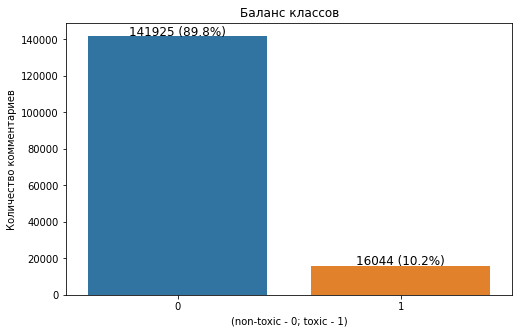

In [15]:
# считаем количество и проценты
counts = comments_data['toxic'].value_counts()
percent = comments_data['toxic'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = sns.countplot(x='toxic', data=comments_data)

# добавляем проценты сверху столбцов
for i, p in enumerate(counts):
    ax.text(i, p + 200, f'{p} ({percent[i]:.1f}%)', ha='center', fontsize=12)

plt.title("Баланс классов")
plt.xlabel("(non-toxic - 0; toxic - 1)")
plt.ylabel("Количество комментариев")
plt.show()

### Частотный анализ слов

In [16]:
# проводим частотный анализ для каждого класса отдельно
toxic_words = ' '.join(comments_data[comments_data['toxic']==1]['lemm_text'].astype(str)).split()
non_toxic_words = ' '.join(comments_data[comments_data['toxic']==0]['lemm_text'].astype(str)).split()

print("Топ слов в токсичных комментариях:", Counter(toxic_words).most_common(20))
print()
print("Топ слов в нетоксичных комментариях:", Counter(non_toxic_words).most_common(20))

Топ слов в токсичных комментариях: [('be', 42263), ('you', 40844), ('i', 30589), ('the', 22855), ('a', 21980), ('to', 17611), ('and', 17316), ('of', 12537), ('not', 12078), ('do', 10961), ('fuck', 10448), ('your', 9600), ('that', 9360), ('it', 9053), ('have', 7528), ('in', 7493), ('my', 6556), ('this', 6035), ('on', 5355), ('for', 5227)]

Топ слов в нетоксичных комментариях: [('be', 480953), ('the', 471127), ('to', 277607), ('i', 246385), ('of', 210991), ('and', 204835), ('a', 193636), ('you', 176376), ('that', 151331), ('not', 145427), ('it', 138722), ('in', 137461), ('have', 113715), ('do', 103316), ('for', 96782), ('this', 90807), ('on', 83792), ('as', 73589), ('article', 71019), ('if', 54879)]


<div style="border: 2px solid black; padding: 10px;">
  <strong>Итоги:</strong>
  <ul>
    <li>Данные сильно несбалансированы. При оценке лучше использовать F1-score, особенно для класса токсичных комментариев, а не только accuracy;</li>  
    <li>Векторизатор (TF-IDF) + классификатор (LogisticRegression/LGBMClassifier/ComplementNB) с учётом дисбаланса должен дать F1 ≥ 0.75, если правильно настроить параметры;</li>  
    <li>Явные токсичные слова - хорошие предикторы, но нужно учитывать, что некоторые слова встречаются в обоих классах.</li>   
  </ul>
</div>

## Моделирование

### Подготовка выборок

In [17]:
# разделяем данные на признаки и целевую переменную
X = comments_data['lemm_text'] # текст после очистки и лемматизации
y = comments_data['toxic']      # целевой признак

# train/test split со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

### Обучение моделей

Для проекта выбраны модели LogisticRegression, ComplementNB и LGBMClassifier, так как они хорошо подходят для задачи классификации токсичных комментариев с дисбалансом классов: 
- Logistic Regression и LGBM позволяют учитывать редкий класс через параметр class_weight='balanced' и часто показывают высокое значение F1, что важно для токсичных комментариев.
- ComplementNB, являющийся модифицированной версией Naive Bayes, лучше справляется с дисбалансом и служит надежным baseline. 

Такой набор моделей обеспечивает баланс между качеством, скоростью обучения и интерпретируемостью.

#### LogisticRegression

In [18]:
# параметры для GridSearch
params_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2']
}

# pipeline с TF-IDF
pipeline_lr = Pipeline([
    ('tfvect', TfidfVectorizer(stop_words='english')),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear'
    ))
])

# GridSearchCV
grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=params_lr,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# замер времени обучения
start_time = time.time()
grid_lr.fit(X_train, y_train)
end_time = time.time()

# вывод результатов
print('LogisticRegression:')
print('Лучшие параметры:', grid_lr.best_params_)
print('Лучшее F1:', grid_lr.best_score_)
print('Время обучения:', round(end_time - start_time, 2), 'секунд')

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ...................model__C=0.01, model__penalty=l2; total time=   8.4s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=   8.2s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=   8.2s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=   9.6s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  10.7s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  10.6s
[CV] END ......................model__C=1, model__penalty=l2; total time=  14.9s
[CV] END ......................model__C=1, model__penalty=l2; total time=  15.3s
[CV] END ......................model__C=1, model__penalty=l2; total time=  15.6s
[CV] END .....................model__C=10, model__penalty=l2; total time=  26.8s
[CV] END .....................model__C=10, model__penalty=l2; total time=  26.4s
[CV] END .....................model__C=10, model_

#### LGBMClassifier

In [19]:
# параметры для GridSearch
params_lgbm = {
    'model__num_leaves': [31, 50],
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [100, 200],
    'model__class_weight': ['balanced']
}

# pipeline с TF-IDF
pipeline_lgbm = Pipeline([
    ('tfvect', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=10)),
    ('model', LGBMClassifier(random_state=RANDOM_STATE))
])

# GridSearchCV
grid_lgbm = GridSearchCV(
    pipeline_lgbm,
    param_grid=params_lgbm,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# замер времени обучения
start_time = time.time()
grid_lgbm.fit(X_train, y_train)
end_time = time.time()

# вывод результатов
print('LGBMClassifier:')
print('Лучшие параметры:', grid_lgbm.best_params_)
print('Лучшее F1:', grid_lgbm.best_score_)
print('Время обучения:', round(end_time - start_time, 2), 'секунд')

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[CV] END model__class_weight=balanced, model__learning_rate=0.05, model__n_estimators=100, model__num_leaves=31; total time= 1.9min


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[CV] END model__class_weight=balanced, model__learning_rate=0.05, model__n_estimators=100, model__num_leaves=31; total time= 1.9min


...

[CV] END model__class_weight=balanced, model__learning_rate=0.1, model__n_estimators=200, model__num_leaves=50; total time= 4.1min


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[CV] END model__class_weight=balanced, model__learning_rate=0.1, model__n_estimators=200, model__num_leaves=50; total time= 4.1min


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBMClassifier:
Лучшие параметры: {'model__class_weight': 'balanced', 'model__learning_rate': 0.1, 'model__n_estimators': 200, 'model__num_leaves': 50}
Лучшее F1: 0.7521484073781121
Время обучения: 4594.62 секунд


#### ComplementNB

In [20]:
# параметры для GridSearch
params_cnb = {
    'model__alpha': [0.5, 1.0, 1.5],
    'model__norm': [True, False]
}

# pipeline с TF-IDF
pipeline_cnb = Pipeline([
    ('tfvect', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=10)),
    ('model', ComplementNB())
])

# GridSearchCV
grid_cnb = GridSearchCV(
    pipeline_cnb,
    param_grid=params_cnb,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# замер времени обучения
start_time = time.time()
grid_cnb.fit(X_train, y_train)
end_time = time.time()

# вывод результатов
print('ComplementNB:')
print('Лучшие параметры:', grid_cnb.best_params_)
print('Лучшее F1:', grid_cnb.best_score_)
print('Время обучения:', round(end_time - start_time, 2), 'секунд')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .................model__alpha=0.5, model__norm=True; total time=  10.1s
[CV] END .................model__alpha=0.5, model__norm=True; total time=   9.8s
[CV] END .................model__alpha=0.5, model__norm=True; total time=  10.0s
[CV] END ................model__alpha=0.5, model__norm=False; total time=  10.0s
[CV] END ................model__alpha=0.5, model__norm=False; total time=   9.9s
[CV] END ................model__alpha=0.5, model__norm=False; total time=  10.0s
[CV] END .................model__alpha=1.0, model__norm=True; total time=  10.3s
[CV] END .................model__alpha=1.0, model__norm=True; total time=  10.1s
[CV] END .................model__alpha=1.0, model__norm=True; total time=  10.3s
[CV] END ................model__alpha=1.0, model__norm=False; total time=  10.3s
[CV] END ................model__alpha=1.0, model__norm=False; total time=  10.4s
[CV] END ................model__alpha=1.0, model_

- На тренировочной выборке лучше всего себя показала модель LogisticRegression с TF-IDF векторизацией для задачи классификации токсичных комментариев. 
- Для подбора гиперпараметров применялся GridSearchCV с оптимизацией F1-score, так как классы в выборке несбалансированы.
- Лучшая модель с параметром C=10 показала значение F1-score 0.76, что превышает требуемый порог качества.
- Время обучения модели составило 347 секунд, что является хорошим результатом с учётом размера датасета и использования кросс-валидации.
- Модель LGBMClassifier преодолела требуемый порог F1-score, но он все равно ниже результата лучшей модели, а время обучения оказалось слишком большим.
- Модель ComplementNB не преодолела требуемый порог метрики, но справилась быстро, что делает ее хорошей базовой моделью для проверки качества основной.

### Проверка лучшей модели

LogisticRegression - лучшая модель:
- Лучшие параметры: {'model__C': 10, 'model__penalty': 'l2'}
- Лучшее F1: 0.7606781525507674
- Время обучения: 347.25 секунд

In [21]:
# проверка лучшей модели на тесте
best_model = grid_lr.best_estimator_
y_pred_test = best_model.predict(X_test)

print("F1 на тесте:", f1_score(y_test, y_pred_test))

F1 на тесте: 0.7623225210666051


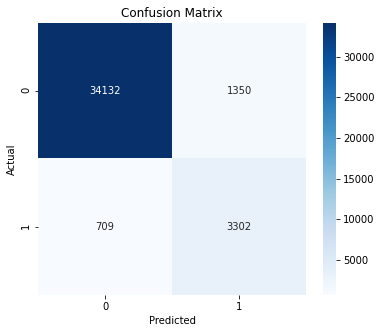

In [22]:
# построим confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Итоговые выводы

**Предобработка данных**
- Текст очищен и лемматизирован;
- Данные проверены на наличие дубликатов и пропусков;
- Изменение типов данных не требуется.

**Исследовательский анализ данных**
- Данные сильно несбалансированы. При оценке лучше использовать F1-score, особенно для класса токсичных комментариев, а не только accuracy;
- Векторизатор (TF-IDF) + классификатор (LogisticRegression/LGBMClassifier/ComplementNB) с учётом дисбаланса должен дать F1 ≥ 0.75, если правильно настроить параметры;
- Явные токсичные слова - хорошие предикторы, но нужно учитывать, что некоторые слова встречаются в обоих классах.

**Моделирование**
- На тренировочной выборке лучше всего себя показала модель LogisticRegression с TF-IDF векторизацией для задачи классификации токсичных комментариев. 
- Для подбора гиперпараметров применялся GridSearchCV с оптимизацией F1-score, так как классы в выборке несбалансированы.
- Лучшая модель с параметром C=10 показала значение F1-score 0.76, что превышает требуемый порог качества.
- Время обучения модели составило 347 секунд, что является хорошим результатом с учётом размера датасета и использования кросс-валидации.
- Модель LGBMClassifier преодолела требуемый порог F1-score, но он все равно ниже результата лучшей модели, а время обучения оказалось слишком большим.
- Модель ComplementNB не преодолела требуемый порог метрики, но справилась быстро, что делает ее хорошей базовой моделью для проверки качества основной.

## Рекомендации заказчику

**1. Использовать Logistic Regression как основную модель**
- Показывает высокое качество классификации (F1 = 0.76) и устойчиво работает на текстах.
- Легко интерпретируется и быстро обучается при увеличении объёма данных.

**2. Регулярно обновлять модель и данные**
- Токсичность комментариев может изменяться со временем, поэтому рекомендовано периодическое переобучение (например, раз в 1–3 месяца).
- Это позволит сохранять высокую точность и актуальность модерации.

**3. Использовать модель как вспомогательный инструмент для модерации**
- Модель автоматически помечает подозрительные комментарии, которые направляются на ручную проверку модератора.
- Это сокращает нагрузку на сотрудников и ускоряет обработку комментариев, но не заменяет полностью человеческую проверку.

**4. Внедрить систему мониторинга метрик**
- Отслеживать F1, точность и полноту на новых данных, чтобы вовремя выявлять снижение качества модели.
- Это позволит своевременно корректировать параметры или добавлять новые данные для обучения.